Критическая область: G > 1.6449
Статистика критерия: 0.9289
Нет достаточных оснований отвергнуть H₀


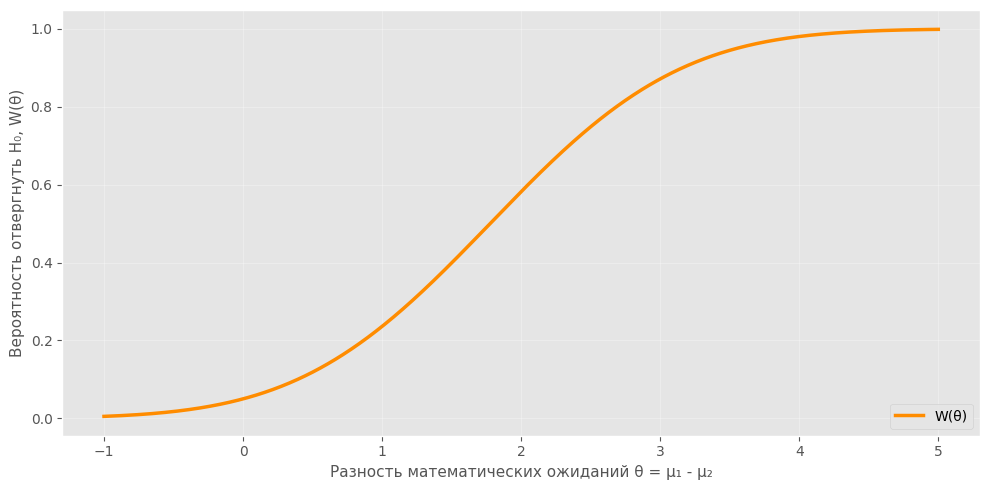

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import scipy.optimize as opt
import seaborn as sns
import math as mt
from skimage.io import imread, imsave

np.random.seed(52)
plt.style.use('ggplot')

sample_group_a = np.array([-1.11, -6.10, 2.42])
sample_group_b = np.array([-2.29, -2.91])

variance_a = 2
variance_b = 1
significance_level = 0.05

mean_a = np.mean(sample_group_a)
mean_b = np.mean(sample_group_b)
size_a = len(sample_group_a)
size_b = len(sample_group_b)

std_error_diff = np.sqrt(variance_a / size_a + variance_b / size_b)
z_statistic = (mean_a - mean_b) / std_error_diff

critical_value = stats.norm.ppf(1 - significance_level)

print(f"Критическая область: G > {critical_value:.4f}")

print(f"Статистика критерия: {z_statistic:.4f}")
if z_statistic < critical_value:
    print("Нет достаточных оснований отвергнуть H₀")
else:
    print("H₀ отвергается в пользу H₁")


theta_values = np.linspace(-1, 5, 1000)

rejection_boundary = stats.norm(0, std_error_diff).ppf(1 - significance_level)

power_function = 1 - stats.norm(theta_values, std_error_diff).cdf(rejection_boundary)

fig, power_plot = plt.subplots(1, 1, figsize=(10, 5))

power_plot.plot(theta_values, power_function, 
                color='darkorange', 
                linewidth=2.5,
                label='W(θ)')

power_plot.set_xlabel('Разность математических ожиданий θ = μ₁ - μ₂', fontsize=11)
power_plot.set_ylabel('Вероятность отвергнуть H₀, W(θ)', fontsize=11)
power_plot.grid(True, alpha=0.3)
power_plot.legend(loc='lower right', fontsize=10)

observed_diff = mean_a - mean_b
observed_power = 1 - stats.norm(observed_diff, std_error_diff).cdf(rejection_boundary)
power_plot.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()
